# Bateria de testes das curvas de juros

Este notebook consome os resultados produzidos pelo pipeline `factory_curve_evaluation` e compara **Bootstrapping**, **Nelson–Siegel**, **Svensson** e **Kernel Ridge**.

A análise está organizada em:

1. qualidade dos DataFrames gerados;
2. ajuste em taxa in-sample e out-of-sample;
3. reprecificação;
4. estabilidade temporal por PCA;
5. forwards implícitos e não arbitragem;
6. previsibilidade por rolldown.

> Taxas são efetivas anuais em decimal. Nos gráficos de erro em taxa, os valores são convertidos para pontos-base (1 bp = 0,0001).

In [1]:
from pathlib import Path
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

METHOD_ORDER = ["bootstrapping", "nelson_siegel", "svensson", "kernel_ridge"]
METHOD_LABELS = {
    "bootstrapping": "Bootstrapping",
    "nelson_siegel": "Nelson–Siegel",
    "svensson": "Svensson",
    "kernel_ridge": "Kernel Ridge",
}
METHOD_COLORS = {
    "bootstrapping": "#1f77b4",
    "nelson_siegel": "#ff7f0e",
    "svensson": "#d62728",
    "kernel_ridge": "#2ca02c",
}
SAMPLE_LABELS = {"in_sample": "In-sample · LTN", "out_of_sample": "Out-of-sample · Swap DI×Pré"}

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "conf").exists():
            return candidate
    raise FileNotFoundError("Não foi possível localizar a raiz do projeto.")

ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = ROOT / "data" / "08_reporting" / "factory_curve" / "evaluation"

FILES = {
    "rate_errors": "rate_errors.parquet",
    "rate_metrics_daily": "rate_metrics_daily.parquet",
    "rate_metrics_summary": "rate_metrics_summary.parquet",
    "repricing_errors": "repricing_errors.parquet",
    "repricing_metrics_daily": "repricing_metrics_daily.parquet",
    "repricing_metrics_summary": "repricing_metrics_summary.parquet",
    "pca_scores_daily": "pca_scores_daily.parquet",
    "pca_loadings": "pca_loadings.parquet",
    "forward_diagnostics_daily": "forward_diagnostics_daily.parquet",
    "forward_violations": "forward_violations.parquet",
    "rolldown_results": "rolldown_results.parquet",
    "rolldown_metrics": "rolldown_metrics.parquet",
}

missing_files = [filename for filename in FILES.values() if not (DATA_DIR / filename).exists()]
if missing_files:
    raise FileNotFoundError(
        "Execute `kedro run --pipeline factory_curve_evaluation` antes do notebook. "
        f"Arquivos ausentes: {missing_files}"
    )

def read_result(name: str, columns=None) -> pd.DataFrame:
    frame = pd.read_parquet(DATA_DIR / FILES[name], columns=columns)
    for column in ("ref_date", "next_ref_date"):
        if column in frame.columns:
            frame[column] = pd.to_datetime(frame[column])
    return frame

print(f"Raiz do projeto: {ROOT}")
print(f"Resultados: {DATA_DIR}")

Raiz do projeto: C:\Users\Dell\OneDrive\Documentos\GitHub\ML-ETTJ26
Resultados: C:\Users\Dell\OneDrive\Documentos\GitHub\ML-ETTJ26\data\08_reporting\factory_curve\evaluation


## 0. Qualidade dos DataFrames

**Objetivo.** Verificar se os resultados estão legíveis e coerentes antes da interpretação econômica: schema, volume, cobertura temporal, metodologias presentes, duplicidades, valores ausentes e valores numéricos não finitos.

A auditoria lê um arquivo por vez para limitar o consumo de memória.

In [2]:
EXPECTED_COLUMNS = {
    "rate_metrics_summary": {"methodology", "sample", "n_observations", "rmse", "mae", "bias"},
    "repricing_metrics_summary": {"methodology", "sample", "n_observations", "rmse", "mae", "bias"},
    "pca_scores_daily": {"methodology", "ref_date", "factor", "score", "explained_variance_ratio"},
    "pca_loadings": {"methodology", "factor", "tenor_bd", "loading"},
    "forward_diagnostics_daily": {"methodology", "ref_date", "n_forwards", "n_violations", "violation_share"},
    "forward_violations": {"methodology", "ref_date", "tenor_bd", "violation_reason"},
    "rolldown_results": {"methodology", "ref_date", "next_ref_date", "isin", "rate_error_direct", "rate_error_taylor"},
    "rolldown_metrics": {"methodology", "tenor_segment", "prediction_method", "rate_rmse", "price_rmse"},
}

quality_rows = []
coverage_rows = []

for dataset_name, filename in FILES.items():
    frame = read_result(dataset_name)
    numeric = frame.select_dtypes(include="number")
    missing_expected = EXPECTED_COLUMNS.get(dataset_name, set()) - set(frame.columns)
    quality_rows.append({
        "dataset": dataset_name,
        "rows": len(frame),
        "columns": len(frame.columns),
        "memory_mb": frame.memory_usage(index=True, deep=True).sum() / 1024**2,
        "duplicate_rows": int(frame.duplicated().sum()),
        "missing_cells": int(frame.isna().sum().sum()),
        "non_finite_numeric": int((~np.isfinite(numeric)).sum().sum()) if not numeric.empty else 0,
        "methodologies": frame["methodology"].nunique() if "methodology" in frame else np.nan,
        "schema_ok": not missing_expected,
        "missing_expected_columns": ", ".join(sorted(missing_expected)),
        "file_mb": (DATA_DIR / filename).stat().st_size / 1024**2,
    })
    if "methodology" in frame and "ref_date" in frame:
        coverage = frame.groupby("methodology")["ref_date"].agg(["min", "max", "nunique"]).reset_index()
        coverage.insert(0, "dataset", dataset_name)
        coverage_rows.append(coverage)
    del frame, numeric
    gc.collect()

quality = pd.DataFrame(quality_rows).sort_values("dataset").reset_index(drop=True)
coverage = pd.concat(coverage_rows, ignore_index=True)
display(quality.style.format({"memory_mb": "{:.1f}", "file_mb": "{:.1f}"}))

,dataset,rows,columns,memory_mb,duplicate_rows,missing_cells,non_finite_numeric,methodologies,schema_ok,missing_expected_columns,file_mb
0,forward_diagnostics_daily,6112,9,0.5,0,0,0,4,True,,0.2
1,forward_violations,1496630,6,98.6,0,16099,16099,4,True,,22.5
2,pca_loadings,2880,5,0.2,0,0,0,4,True,,0.0
3,pca_scores_daily,18318,5,1.0,0,0,0,4,True,,0.2
4,rate_errors,1557718,9,160.7,0,1490862,1490862,4,True,,29.6
5,rate_metrics_daily,12176,8,1.0,0,0,0,4,True,,0.5
6,rate_metrics_summary,8,7,0.0,0,0,0,4,True,,0.0
7,repricing_errors,1557718,10,180.0,0,300,300,4,True,,49.9
8,repricing_metrics_daily,12176,9,1.1,0,0,0,4,True,,0.6
9,repricing_metrics_summary,8,8,0.0,0,0,0,4,True,,0.0


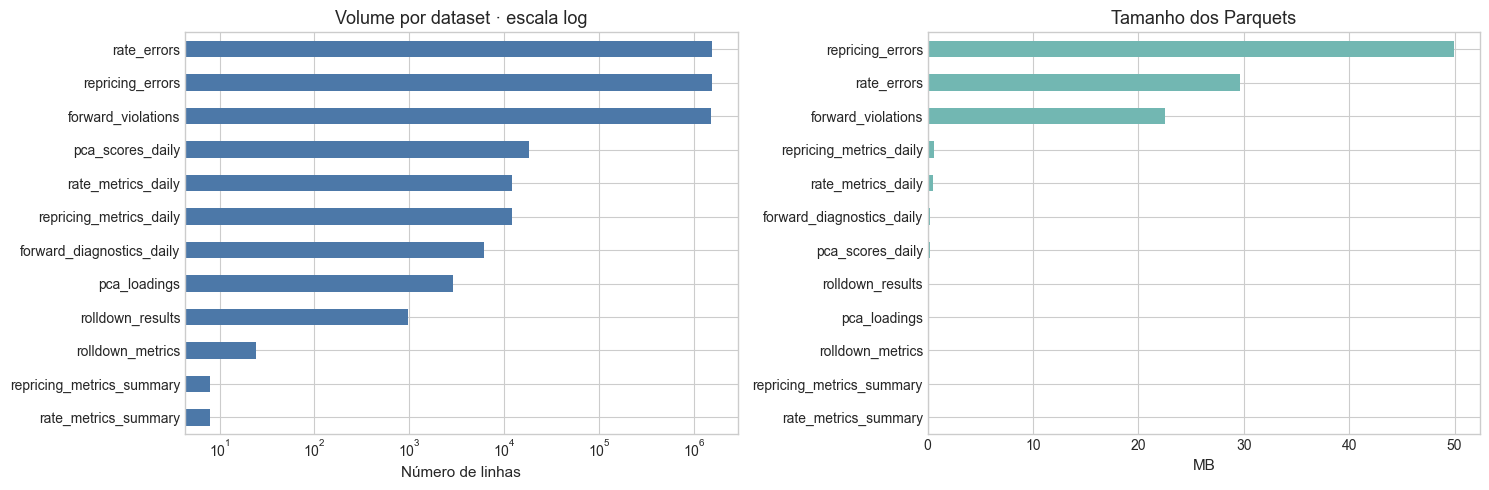

,dataset,methodology,min,max,nunique
20,forward_diagnostics_daily,Bootstrapping,2020-01-02,2026-01-30,1528
21,forward_diagnostics_daily,Kernel Ridge,2020-01-02,2026-01-30,1528
22,forward_diagnostics_daily,Nelson–Siegel,2020-01-02,2026-01-30,1528
23,forward_diagnostics_daily,Svensson,2020-01-02,2026-01-30,1528
24,forward_violations,Bootstrapping,2020-03-13,2026-01-28,126
25,forward_violations,Kernel Ridge,2022-03-22,2025-12-08,8
26,forward_violations,Nelson–Siegel,2020-03-17,2025-01-08,19
27,forward_violations,Svensson,2020-01-06,2026-01-23,728
16,pca_scores_daily,Bootstrapping,2020-01-03,2026-01-30,1527
17,pca_scores_daily,Kernel Ridge,2020-01-03,2026-01-30,1525


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

quality.sort_values("rows").plot.barh(
    x="dataset", y="rows", logx=True, ax=axes[0], color="#4c78a8", legend=False
)
axes[0].set_title("Volume por dataset · escala log")
axes[0].set_xlabel("Número de linhas")
axes[0].set_ylabel("")

quality.sort_values("file_mb").plot.barh(
    x="dataset", y="file_mb", ax=axes[1], color="#72b7b2", legend=False
)
axes[1].set_title("Tamanho dos Parquets")
axes[1].set_xlabel("MB")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(
    coverage.assign(
        methodology=lambda x: x["methodology"].map(METHOD_LABELS).fillna(x["methodology"])
    ).sort_values(["dataset", "methodology"])
)

### Status específicos de domínio

Os valores ausentes em `repricing_errors` podem ser intencionais quando uma taxa estimada é menor ou igual a −100%. Esses casos devem aparecer em `pricing_status`, e não ser tratados como falha silenciosa. Da mesma forma, forwards não representáveis devem permanecer classificados em `violation_reason`.

In [4]:
repricing_status = read_result("repricing_errors", columns=["methodology", "sample", "pricing_status"])
status_table = (
    repricing_status.groupby(["methodology", "sample", "pricing_status"], observed=True)
    .size().rename("points").reset_index()
)
display(status_table.sort_values(["methodology", "sample", "pricing_status"]))
del repricing_status
gc.collect()

,methodology,sample,pricing_status,points
0,bootstrapping,in_sample,valid,16714
1,bootstrapping,out_of_sample,valid,372717
2,kernel_ridge,in_sample,valid,16714
3,kernel_ridge,out_of_sample,valid,372711
4,nelson_siegel,in_sample,valid,16714
5,nelson_siegel,out_of_sample,valid,372717
6,svensson,in_sample,valid,16714
7,svensson,out_of_sample,invalid_estimated_rate,100
8,svensson,out_of_sample,valid,372617


2915

## 1. RMSE em taxa

**Objetivo.** Medir a distância entre a taxa estimada pela curva e a taxa observada:

- **in-sample:** LTN no prazo exato em dias úteis;
- **out-of-sample:** taxas de swap DI×Pré não utilizadas no ajuste dos modelos.

Além do RMSE global, observamos a evolução diária suavizada em 21 pregões e a cauda da distribuição dos erros absolutos.

,methodology,sample,n_observations,rmse,mae,bias,max_abs_error,rmse_bp,mae_bp,bias_bp
0,Bootstrapping,In-sample · LTN,16714,0.000092,0.000025,-0.000007,0.005832,0.924309,0.248077,-0.069033
6,Kernel Ridge,In-sample · LTN,16714,0.002360,0.000989,0.000020,0.054987,23.602375,9.889567,0.204685
4,Svensson,In-sample · LTN,16714,0.002406,0.000943,-0.000140,0.083337,24.061946,9.428554,-1.400259
2,Nelson–Siegel,In-sample · LTN,16714,0.004068,0.001948,0.000986,0.053059,40.675094,19.475832,9.855873
1,Bootstrapping,Out-of-sample · Swap DI×Pré,372717,0.004086,0.002254,0.001052,0.192015,40.858739,22.542559,10.521035
7,Kernel Ridge,Out-of-sample · Swap DI×Pré,372711,0.005318,0.002801,0.001286,0.217522,53.176263,28.012803,12.862084
3,Nelson–Siegel,Out-of-sample · Swap DI×Pré,372717,0.006461,0.003931,0.002283,0.100271,64.612904,39.307461,22.826304
5,Svensson,Out-of-sample · Swap DI×Pré,372717,0.075645,0.018266,-0.008286,4.034560,756.448550,182.663915,-82.860349


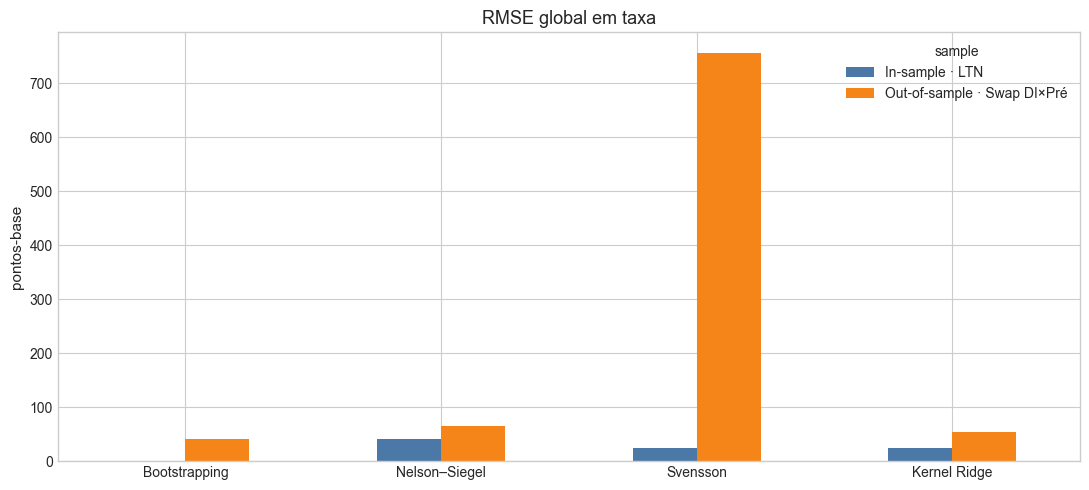

In [5]:
rate_summary = read_result("rate_metrics_summary")
rate_summary["rmse_bp"] = rate_summary["rmse"] * 10_000
rate_summary["mae_bp"] = rate_summary["mae"] * 10_000
rate_summary["bias_bp"] = rate_summary["bias"] * 10_000

display(
    rate_summary.assign(
        methodology=lambda x: x["methodology"].map(METHOD_LABELS),
        sample=lambda x: x["sample"].map(SAMPLE_LABELS),
    ).sort_values(["sample", "rmse_bp"])
)

rate_bar = rate_summary.pivot(index="methodology", columns="sample", values="rmse_bp").reindex(METHOD_ORDER)
rate_bar.index = rate_bar.index.map(METHOD_LABELS)
rate_bar = rate_bar.rename(columns=SAMPLE_LABELS)
ax = rate_bar.plot.bar(color=["#4c78a8", "#f58518"], figsize=(11, 5))
ax.set_title("RMSE global em taxa")
ax.set_ylabel("pontos-base")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

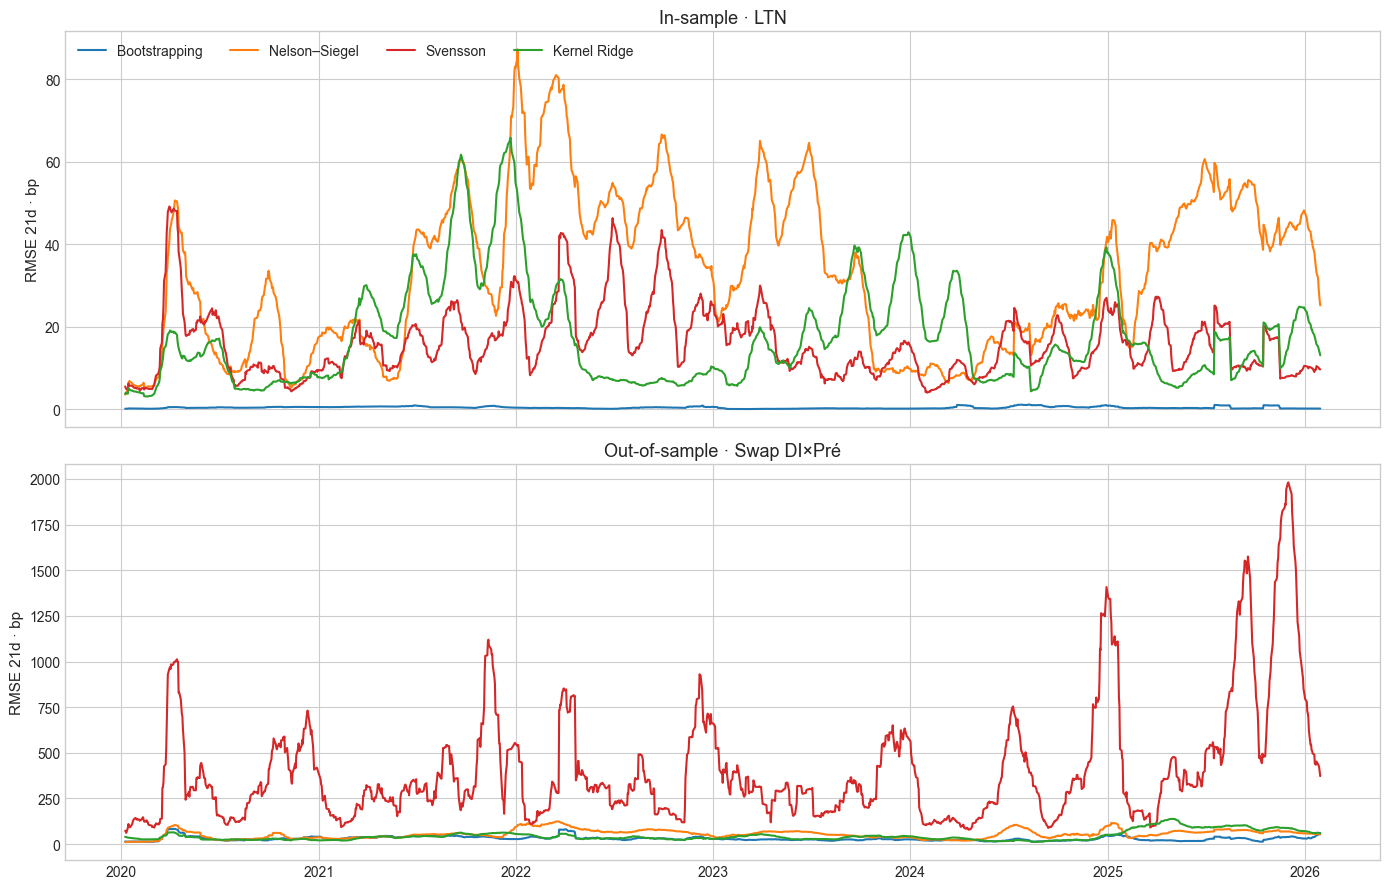

15527

In [6]:
rate_daily = read_result("rate_metrics_daily")
rate_daily["rmse_bp_21d"] = (
    rate_daily.sort_values("ref_date")
    .groupby(["methodology", "sample"], observed=True)["rmse"]
    .transform(lambda series: series.rolling(21, min_periods=5).mean())
    * 10_000
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for axis, sample in zip(axes, ["in_sample", "out_of_sample"]):
    subset = rate_daily.loc[rate_daily["sample"].eq(sample)]
    for method in METHOD_ORDER:
        line = subset.loc[subset["methodology"].eq(method)]
        axis.plot(line["ref_date"], line["rmse_bp_21d"], label=METHOD_LABELS[method], color=METHOD_COLORS[method], linewidth=1.5)
    axis.set_title(SAMPLE_LABELS[sample])
    axis.set_ylabel("RMSE 21d · bp")
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].legend(ncol=4, loc="upper left")
plt.tight_layout()
plt.show()
del rate_daily
gc.collect()

In [7]:
rate_errors = read_result("rate_errors", columns=["methodology", "sample", "rate_error"])
rate_errors["abs_error_bp"] = rate_errors["rate_error"].abs() * 10_000
rate_quantiles = (
    rate_errors.groupby(["methodology", "sample"], observed=True)["abs_error_bp"]
    .quantile([0.50, 0.95, 0.99]).unstack().rename(columns={0.50: "p50", 0.95: "p95", 0.99: "p99"}).reset_index()
)
display(rate_quantiles.sort_values(["sample", "p95"]))
del rate_errors
gc.collect()

,methodology,sample,p50,p95,p99
0,bootstrapping,in_sample,0.034658,0.966048,2.243664
6,svensson,in_sample,4.303752,33.551800,99.705310
2,kernel_ridge,in_sample,4.157272,46.125293,110.887854
4,nelson_siegel,in_sample,7.732640,96.206618,180.190536
1,bootstrapping,out_of_sample,13.306103,71.682874,120.985031
3,kernel_ridge,out_of_sample,14.899791,97.649808,226.030091
5,nelson_siegel,out_of_sample,22.794343,139.007265,239.223348
7,svensson,out_of_sample,19.557416,782.285128,"3,450.988161"


0

## 2. Teste de reprecificação

**Objetivo.** Verificar se as taxas das curvas reproduzem preços economicamente consistentes:

- preço observado das LTN no in-sample;
- preço zero cupom teórico derivado da taxa DI×Pré no out-of-sample.

Comparamos RMSE em unidades monetárias, erro relativo e aderência entre preço observado e estimado. Pontos com `pricing_status != valid` não entram nas métricas agregadas.

,methodology,sample,n_observations,rmse,mae,bias,mape,max_abs_error,mape_pct
0,Bootstrapping,In-sample · LTN,16714,0.361591,0.238383,0.167777,0.000289,9.883696,0.028878
4,Svensson,In-sample · LTN,16714,1.359048,0.704625,0.066463,0.000901,43.628515,0.090061
2,Nelson–Siegel,In-sample · LTN,16714,1.664664,1.097067,-0.085939,0.001386,30.672466,0.138581
6,Kernel Ridge,In-sample · LTN,16714,1.862274,0.709425,0.185837,0.000890,93.614884,0.088989
7,Kernel Ridge,Out-of-sample · Swap DI×Pré,372711,9.107121,4.614682,-2.236865,0.019285,205.403681,1.928519
1,Bootstrapping,Out-of-sample · Swap DI×Pré,372717,10.174865,5.019334,-2.695553,0.016717,393.628059,1.671720
3,Nelson–Siegel,Out-of-sample · Swap DI×Pré,372717,15.468374,6.344055,-2.972336,0.024142,"1,102.037452",2.414190
5,Svensson,Out-of-sample · Swap DI×Pré,372617,"1,517,196,978,978,880,385,143,002,179,571,946,0...","2,485,551,917,329,732,088,047,255,182,707,030,1...","2,485,551,917,329,732,088,047,255,182,707,030,1...","13,038,031,186,073,391,585,083,376,392,514,584,...","926,132,876,949,119,161,652,860,614,553,505,420...","1,303,803,118,607,339,226,208,183,537,670,692,2..."


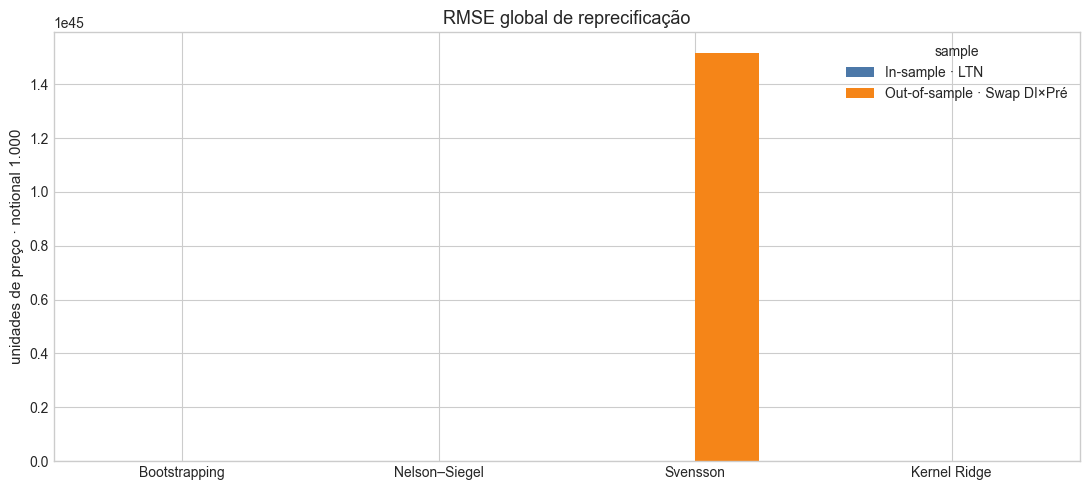

In [8]:
price_summary = read_result("repricing_metrics_summary")
display(
    price_summary.assign(
        methodology=lambda x: x["methodology"].map(METHOD_LABELS),
        sample=lambda x: x["sample"].map(SAMPLE_LABELS),
        mape_pct=lambda x: x["mape"] * 100,
    ).sort_values(["sample", "rmse"])
)

price_bar = price_summary.pivot(index="methodology", columns="sample", values="rmse").reindex(METHOD_ORDER)
price_bar.index = price_bar.index.map(METHOD_LABELS)
price_bar = price_bar.rename(columns=SAMPLE_LABELS)
ax = price_bar.plot.bar(color=["#4c78a8", "#f58518"], figsize=(11, 5))
ax.set_title("RMSE global de reprecificação")
ax.set_ylabel("unidades de preço · notional 1.000")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

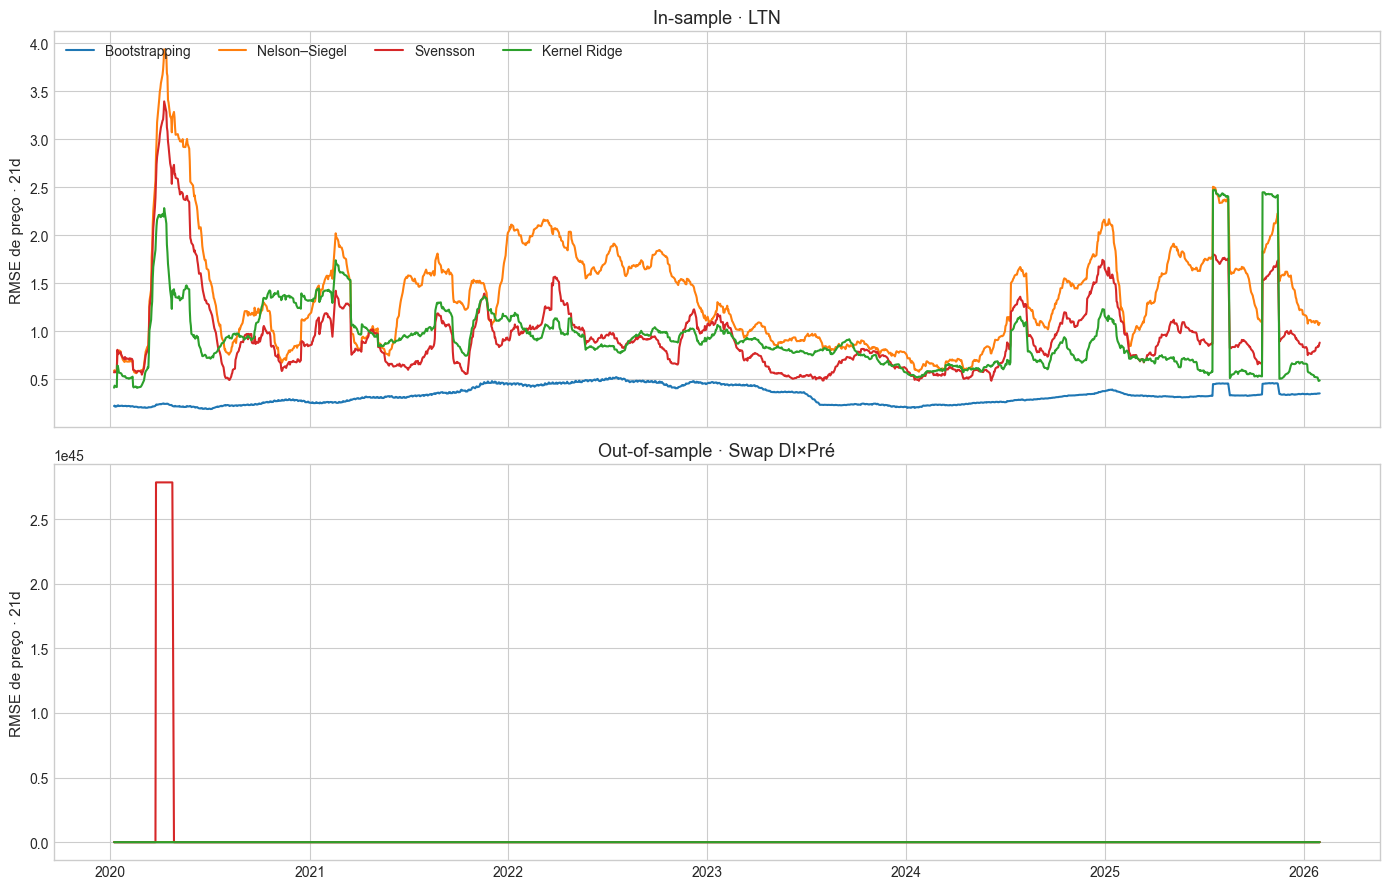

10853

In [9]:
price_daily = read_result("repricing_metrics_daily")
price_daily["rmse_21d"] = (
    price_daily.sort_values("ref_date")
    .groupby(["methodology", "sample"], observed=True)["rmse"]
    .transform(lambda series: series.rolling(21, min_periods=5).mean())
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for axis, sample in zip(axes, ["in_sample", "out_of_sample"]):
    subset = price_daily.loc[price_daily["sample"].eq(sample)]
    for method in METHOD_ORDER:
        line = subset.loc[subset["methodology"].eq(method)]
        axis.plot(line["ref_date"], line["rmse_21d"], label=METHOD_LABELS[method], color=METHOD_COLORS[method], linewidth=1.5)
    axis.set_title(SAMPLE_LABELS[sample])
    axis.set_ylabel("RMSE de preço · 21d")
axes[0].legend(ncol=4, loc="upper left")
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()
del price_daily
gc.collect()

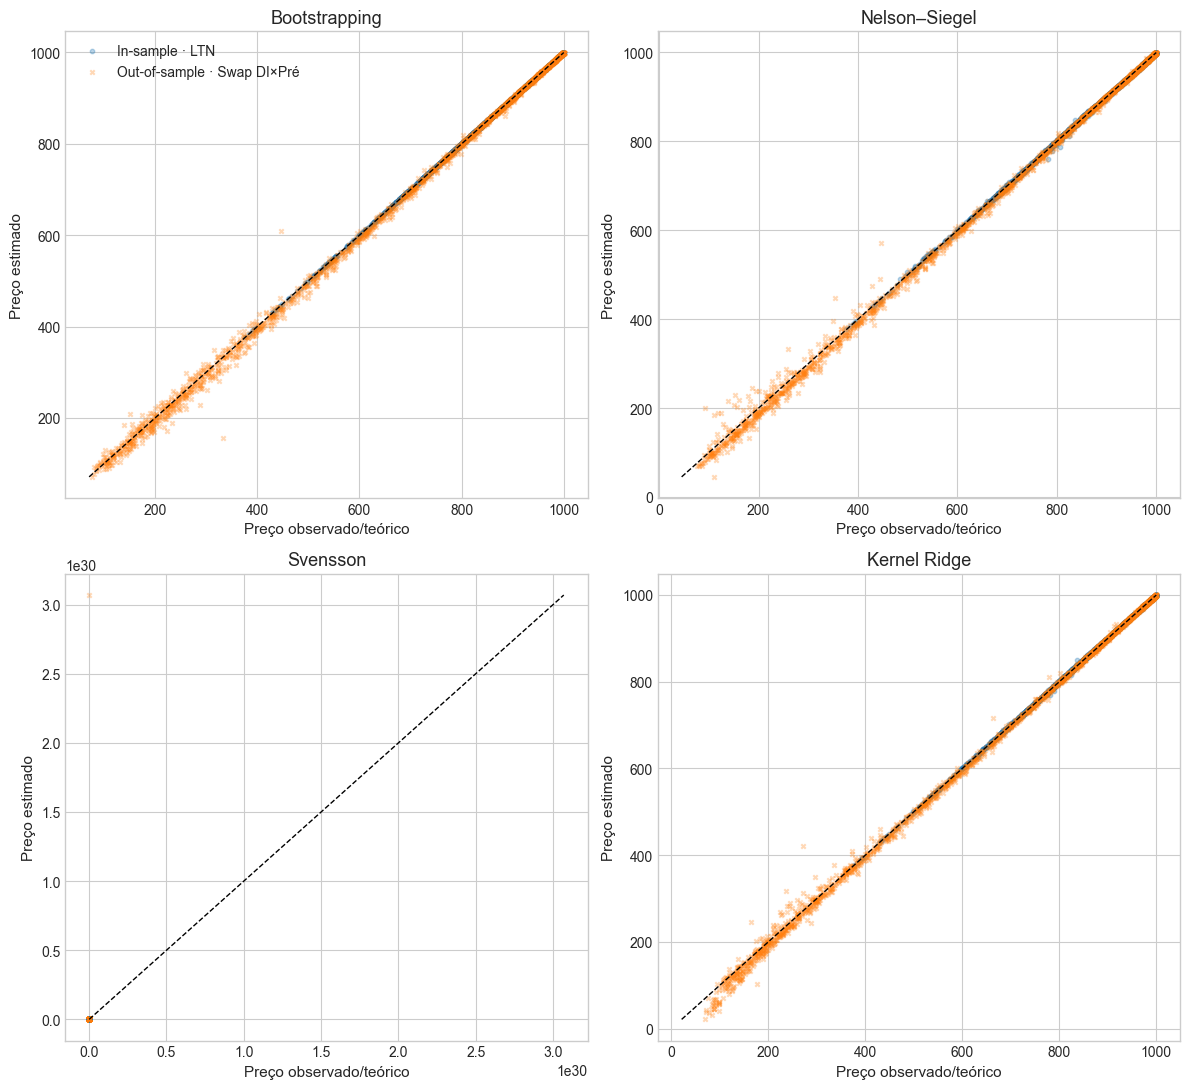

6976

In [10]:
price_points = read_result(
    "repricing_errors",
    columns=["methodology", "sample", "observed_price", "estimated_price", "pricing_status"],
)
valid_prices = price_points.loc[price_points["pricing_status"].eq("valid")].copy()
sampled_prices = pd.concat(
    [group.sample(min(len(group), 2_000), random_state=42) for _, group in valid_prices.groupby(["methodology", "sample"], observed=True)],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for axis, method in zip(axes.flat, METHOD_ORDER):
    subset = sampled_prices.loc[sampled_prices["methodology"].eq(method)]
    for sample, marker in [("in_sample", "o"), ("out_of_sample", "x")]:
        points = subset.loc[subset["sample"].eq(sample)]
        axis.scatter(points["observed_price"], points["estimated_price"], s=10, alpha=0.30, marker=marker, label=SAMPLE_LABELS[sample])
    limits = [subset[["observed_price", "estimated_price"]].min().min(), subset[["observed_price", "estimated_price"]].max().max()]
    axis.plot(limits, limits, "--", color="black", linewidth=1)
    axis.set_title(METHOD_LABELS[method])
    axis.set_xlabel("Preço observado/teórico")
    axis.set_ylabel("Preço estimado")
axes[0, 0].legend()
plt.tight_layout()
plt.show()
del price_points, valid_prices, sampled_prices
gc.collect()

## 3. Estabilidade temporal por PCA

**Objetivo.** Decompor as mudanças diárias de cada curva em três movimentos típicos:

- **level:** deslocamento aproximadamente paralelo;
- **slope:** mudança de inclinação entre curto e longo prazo;
- **curvature:** movimento relativo do miolo contra as pontas.

Os scores mostram quando cada choque ocorreu. Os loadings mostram quais vencimentos participam de cada fator. A variância explicada informa quanto dos movimentos diários é resumido pelos três fatores.

factor,curvature · %,level · %,slope · %
methodology,,,
Bootstrapping,0.858000,96.220000,1.999000
Nelson–Siegel,1.639000,96.391000,1.364000
Svensson,0.003000,0.110000,99.883000
Kernel Ridge,3.457000,4.962000,89.380000


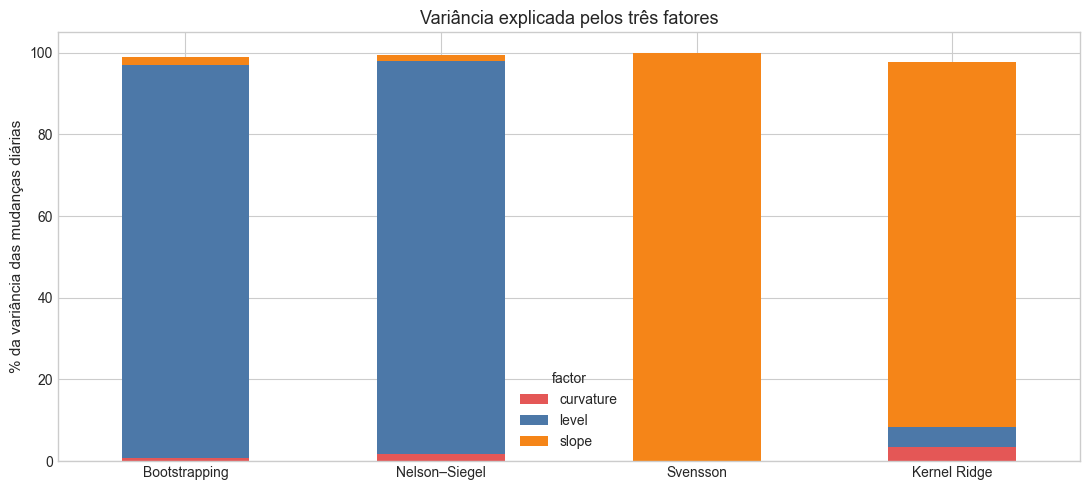

In [11]:
pca_scores = read_result("pca_scores_daily")
pca_loadings = read_result("pca_loadings")

explained = (
    pca_scores[["methodology", "factor", "explained_variance_ratio"]]
    .drop_duplicates()
    .pivot(index="methodology", columns="factor", values="explained_variance_ratio")
    .reindex(METHOD_ORDER)
)
display((explained * 100).round(3).rename(index=METHOD_LABELS).add_suffix(" · %"))

ax = (explained * 100).rename(index=METHOD_LABELS).plot.bar(stacked=True, figsize=(11, 5), color={"level": "#4c78a8", "slope": "#f58518", "curvature": "#e45756"})
ax.set_title("Variância explicada pelos três fatores")
ax.set_ylabel("% da variância das mudanças diárias")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

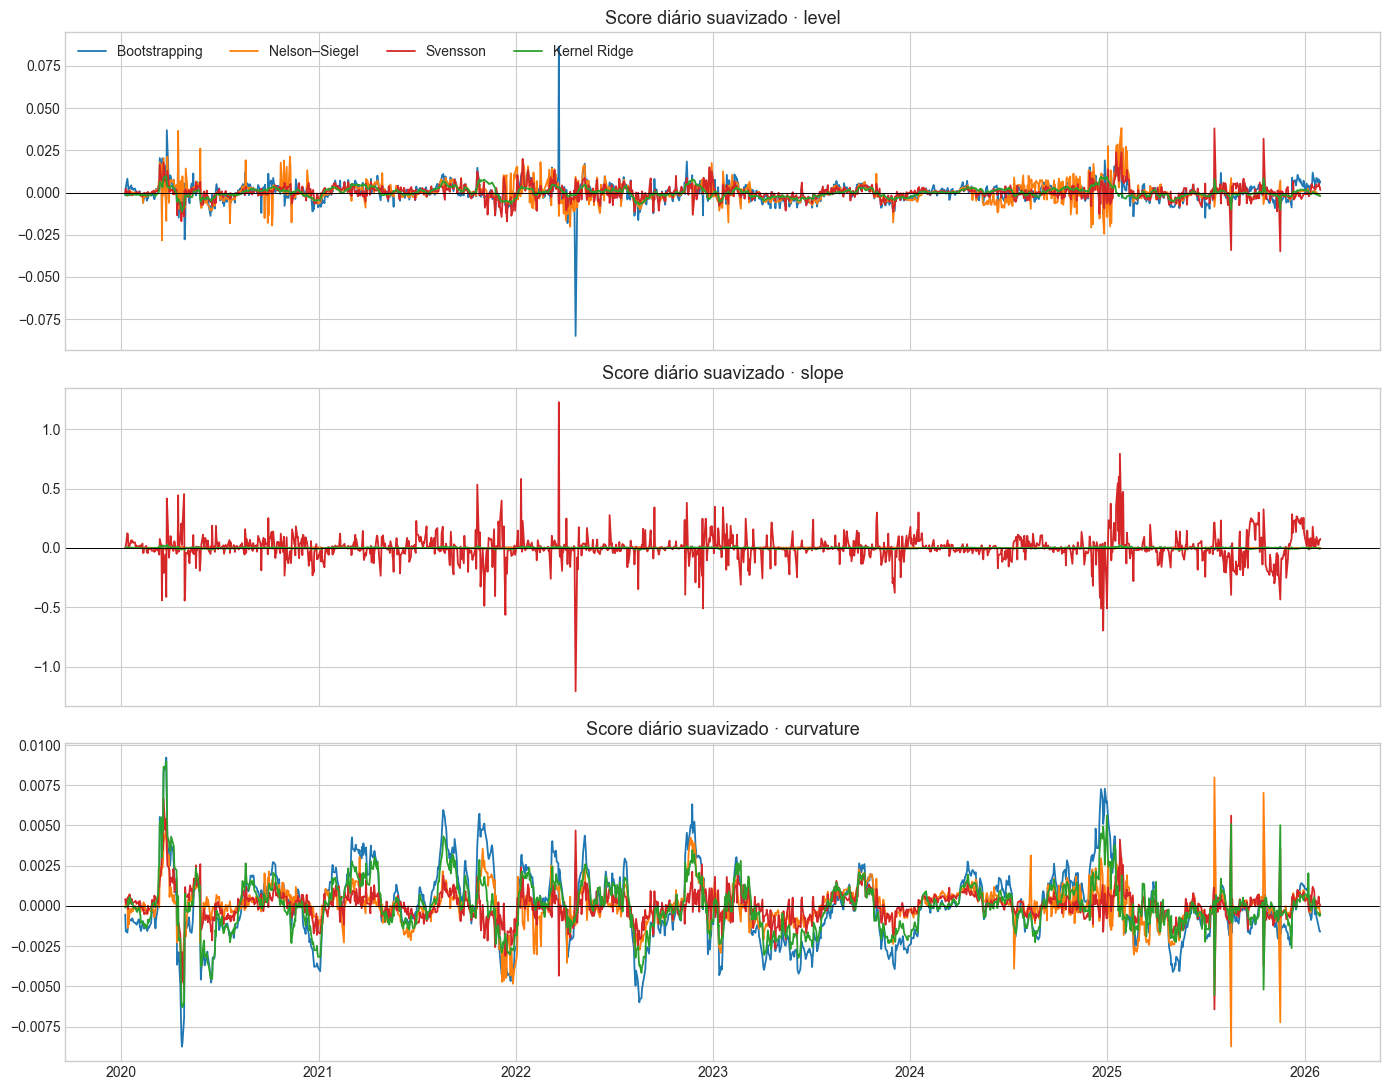

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
for axis, factor in zip(axes, ["level", "slope", "curvature"]):
    factor_scores = pca_scores.loc[pca_scores["factor"].eq(factor)].copy()
    factor_scores["score_21d"] = (
        factor_scores.sort_values("ref_date")
        .groupby("methodology", observed=True)["score"]
        .transform(lambda series: series.rolling(21, min_periods=5).mean())
    )
    for method in METHOD_ORDER:
        line = factor_scores.loc[factor_scores["methodology"].eq(method)]
        axis.plot(line["ref_date"], line["score_21d"], label=METHOD_LABELS[method], color=METHOD_COLORS[method], linewidth=1.3)
    axis.axhline(0, color="black", linewidth=0.7)
    axis.set_title(f"Score diário suavizado · {factor}")
axes[0].legend(ncol=4, loc="upper left")
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

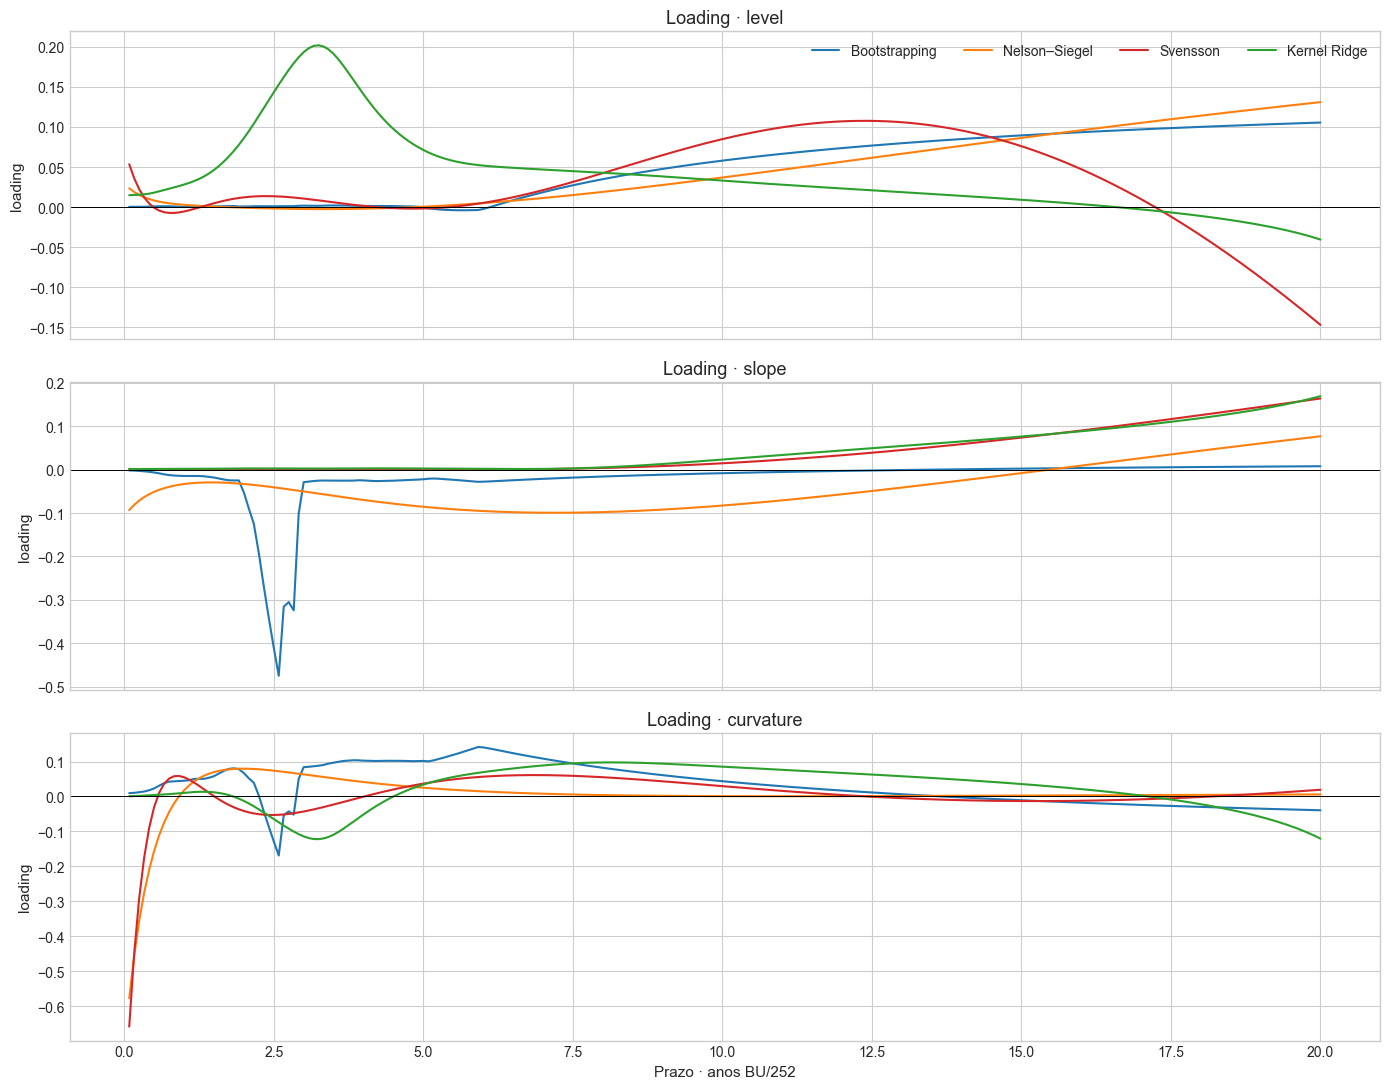

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
for axis, factor in zip(axes, ["level", "slope", "curvature"]):
    subset = pca_loadings.loc[pca_loadings["factor"].eq(factor)]
    for method in METHOD_ORDER:
        line = subset.loc[subset["methodology"].eq(method)]
        axis.plot(line["tenor_bd"] / 252, line["loading"], label=METHOD_LABELS[method], color=METHOD_COLORS[method])
    axis.axhline(0, color="black", linewidth=0.7)
    axis.set_title(f"Loading · {factor}")
    axis.set_ylabel("loading")
axes[-1].set_xlabel("Prazo · anos BU/252")
axes[0].legend(ncol=4, loc="upper right")
plt.tight_layout()
plt.show()

## 4. Forwards implícitos e hipótese de não arbitragem

**Objetivo.** Detectar regiões em que os fatores de desconto implicam forwards inválidos ou fora dos limites econômicos configurados para a curva nominal BRL.

Uma violação não prova, isoladamente, arbitragem executável: pode refletir ruído, extrapolação ou limites econômicos muito restritivos. Entretanto, concentração persistente ou grande extensão de vértices violados é um sinal importante de instabilidade da metodologia.

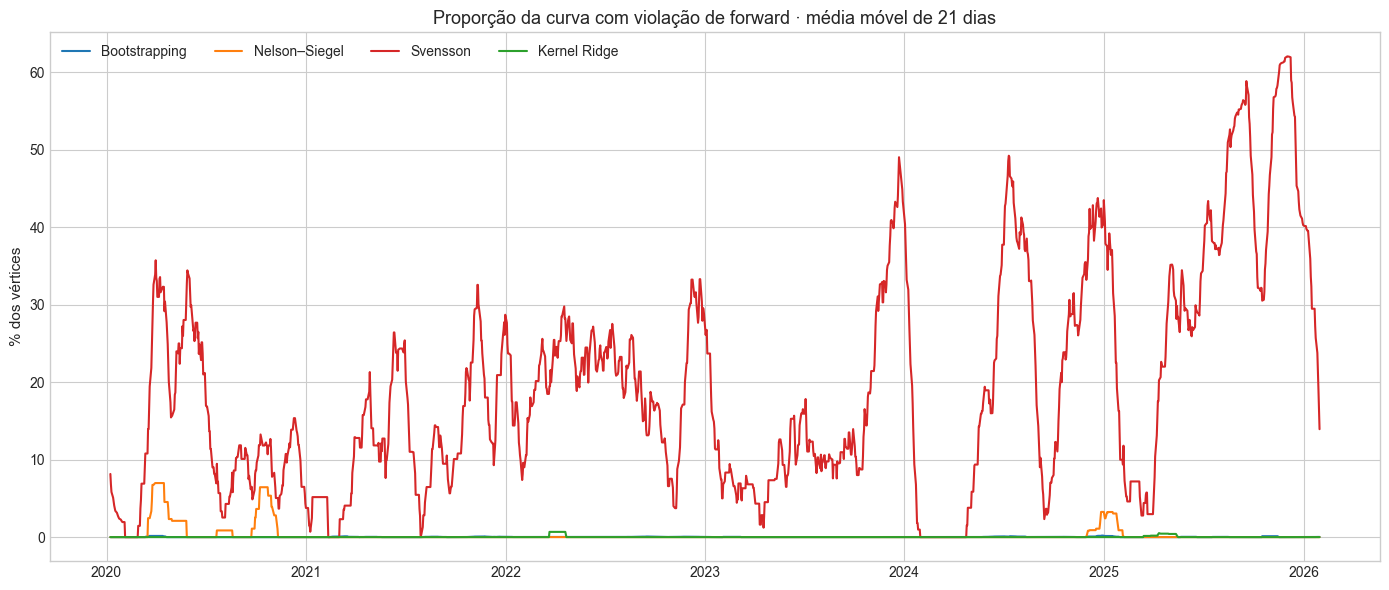

In [14]:
forward_daily = read_result("forward_diagnostics_daily")
forward_daily["violation_share_21d"] = (
    forward_daily.sort_values("ref_date")
    .groupby("methodology", observed=True)["violation_share"]
    .transform(lambda series: series.rolling(21, min_periods=5).mean())
    * 100
)

fig, ax = plt.subplots(figsize=(14, 6))
for method in METHOD_ORDER:
    line = forward_daily.loc[forward_daily["methodology"].eq(method)]
    ax.plot(line["ref_date"], line["violation_share_21d"], label=METHOD_LABELS[method], color=METHOD_COLORS[method], linewidth=1.5)
ax.set_title("Proporção da curva com violação de forward · média móvel de 21 dias")
ax.set_ylabel("% dos vértices")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(ncol=4, loc="upper left")
plt.tight_layout()
plt.show()

,methodology,violation_reason,points,affected_dates,first_date,last_date
1,bootstrapping,below_minimum,1349,115,2020-03-13,2025-12-08
0,bootstrapping,above_maximum,124,12,2025-10-17,2026-01-28
2,kernel_ridge,above_maximum,1042,8,2022-03-22,2025-12-08
3,kernel_ridge,invalid_forward,317,1,2022-03-22,2022-03-22
4,nelson_siegel,below_minimum,21715,19,2020-03-17,2025-01-08
6,svensson,below_minimum,1353292,639,2020-01-06,2026-01-08
5,svensson,above_maximum,111059,89,2020-03-26,2026-01-23
7,svensson,invalid_forward,7732,13,2020-03-17,2024-12-31


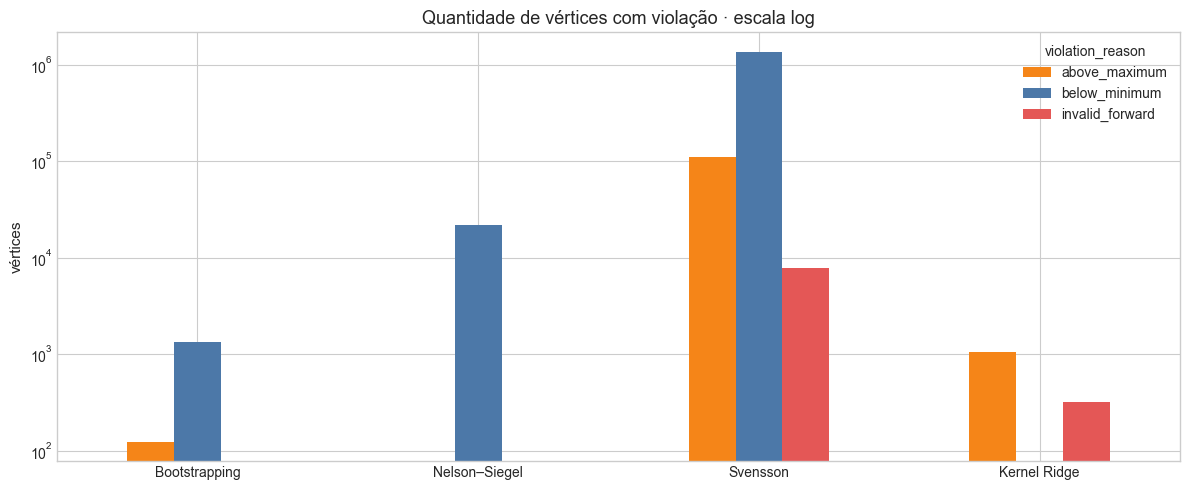

32344

In [15]:
forward_violations = read_result(
    "forward_violations",
    columns=["methodology", "ref_date", "tenor_bd", "violation_reason", "annualized_log_forward"],
)
violation_summary = (
    forward_violations.groupby(["methodology", "violation_reason"], observed=True)
    .agg(points=("tenor_bd", "size"), affected_dates=("ref_date", "nunique"), first_date=("ref_date", "min"), last_date=("ref_date", "max"))
    .reset_index()
)
display(violation_summary.sort_values(["methodology", "points"], ascending=[True, False]))

violation_bar = violation_summary.pivot(index="methodology", columns="violation_reason", values="points").fillna(0).reindex(METHOD_ORDER)
violation_bar.index = violation_bar.index.map(METHOD_LABELS)
ax = violation_bar.plot.bar(figsize=(12, 5), logy=True, color={"below_minimum": "#4c78a8", "above_maximum": "#f58518", "invalid_forward": "#e45756"})
ax.set_title("Quantidade de vértices com violação · escala log")
ax.set_ylabel("vértices")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
del forward_violations
gc.collect()

## 5. Previsibilidade por rolldown

**Objetivo.** Usar a curva observada em D para prever a taxa e o preço de uma LTN repetida em D+1, quando seu prazo cai de `T` para `T−1` dia útil.

A amostra mensal contém até um ponto curto, dois médios e um longo. Comparamos:

- **direct:** leitura direta da curva de D em `T−1`;
- **taylor:** expansão de segunda ordem usando derivadas centrais da curva, delta e convexidade numéricos do preço.

,methodology,tenor_segment,prediction_method,n_observations,rate_rmse,rate_mae,rate_bias,price_rmse,price_mae,price_bias,rate_rmse_bp
0,Bootstrapping,long,direct,25,0.000833,0.000664,0.000038,2.085305,1.630659,0.101201,8.325620
18,Kernel Ridge,long,direct,25,0.000936,0.000778,0.000018,2.339851,1.944161,0.181074,9.363627
12,Svensson,long,direct,25,0.001061,0.000872,-0.000070,2.686874,2.210279,0.345233,10.614327
6,Nelson–Siegel,long,direct,25,0.001342,0.001162,0.000118,3.329835,2.859379,-0.106631,13.416404
1,Bootstrapping,long,taylor,25,0.000831,0.000664,0.000041,2.080472,1.628105,0.093703,8.309881
19,Kernel Ridge,long,taylor,25,0.000936,0.000778,0.000018,2.339851,1.944161,0.181074,9.363626
13,Svensson,long,taylor,25,0.001061,0.000872,-0.000070,2.686874,2.210279,0.345233,10.614327
7,Nelson–Siegel,long,taylor,25,0.001342,0.001162,0.000118,3.329835,2.859379,-0.106631,13.416404
2,Bootstrapping,medium,direct,146,0.001020,0.000750,0.000064,2.118989,1.593612,0.089930,10.199426
20,Kernel Ridge,medium,direct,146,0.001089,0.000843,-0.000094,2.318862,1.787748,0.455077,10.887086


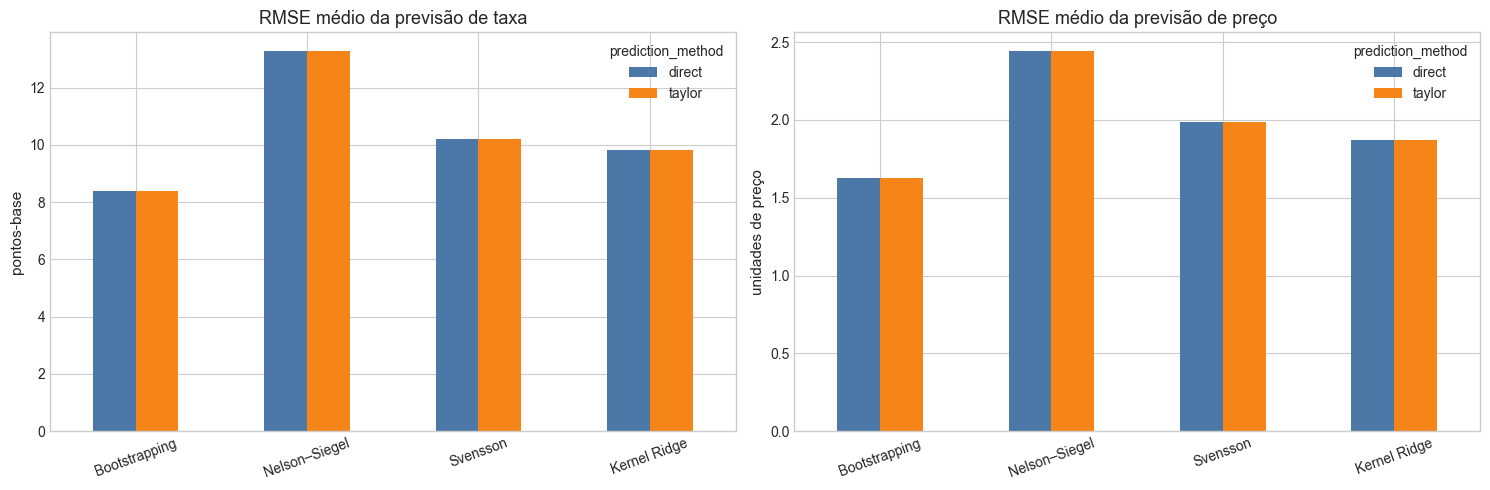

In [16]:
rolldown_metrics = read_result("rolldown_metrics")
rolldown_metrics["rate_rmse_bp"] = rolldown_metrics["rate_rmse"] * 10_000
display(
    rolldown_metrics.assign(
        methodology=lambda x: x["methodology"].map(METHOD_LABELS)
    ).sort_values(["tenor_segment", "prediction_method", "rate_rmse_bp"])
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
rate_roll = rolldown_metrics.groupby(["methodology", "prediction_method"], observed=True)["rate_rmse_bp"].mean().unstack().reindex(METHOD_ORDER)
rate_roll.index = rate_roll.index.map(METHOD_LABELS)
rate_roll.plot.bar(ax=axes[0], color={"direct": "#4c78a8", "taylor": "#f58518"})
axes[0].set_title("RMSE médio da previsão de taxa")
axes[0].set_ylabel("pontos-base")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

price_roll = rolldown_metrics.groupby(["methodology", "prediction_method"], observed=True)["price_rmse"].mean().unstack().reindex(METHOD_ORDER)
price_roll.index = price_roll.index.map(METHOD_LABELS)
price_roll.plot.bar(ax=axes[1], color={"direct": "#4c78a8", "taylor": "#f58518"})
axes[1].set_title("RMSE médio da previsão de preço")
axes[1].set_ylabel("unidades de preço")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

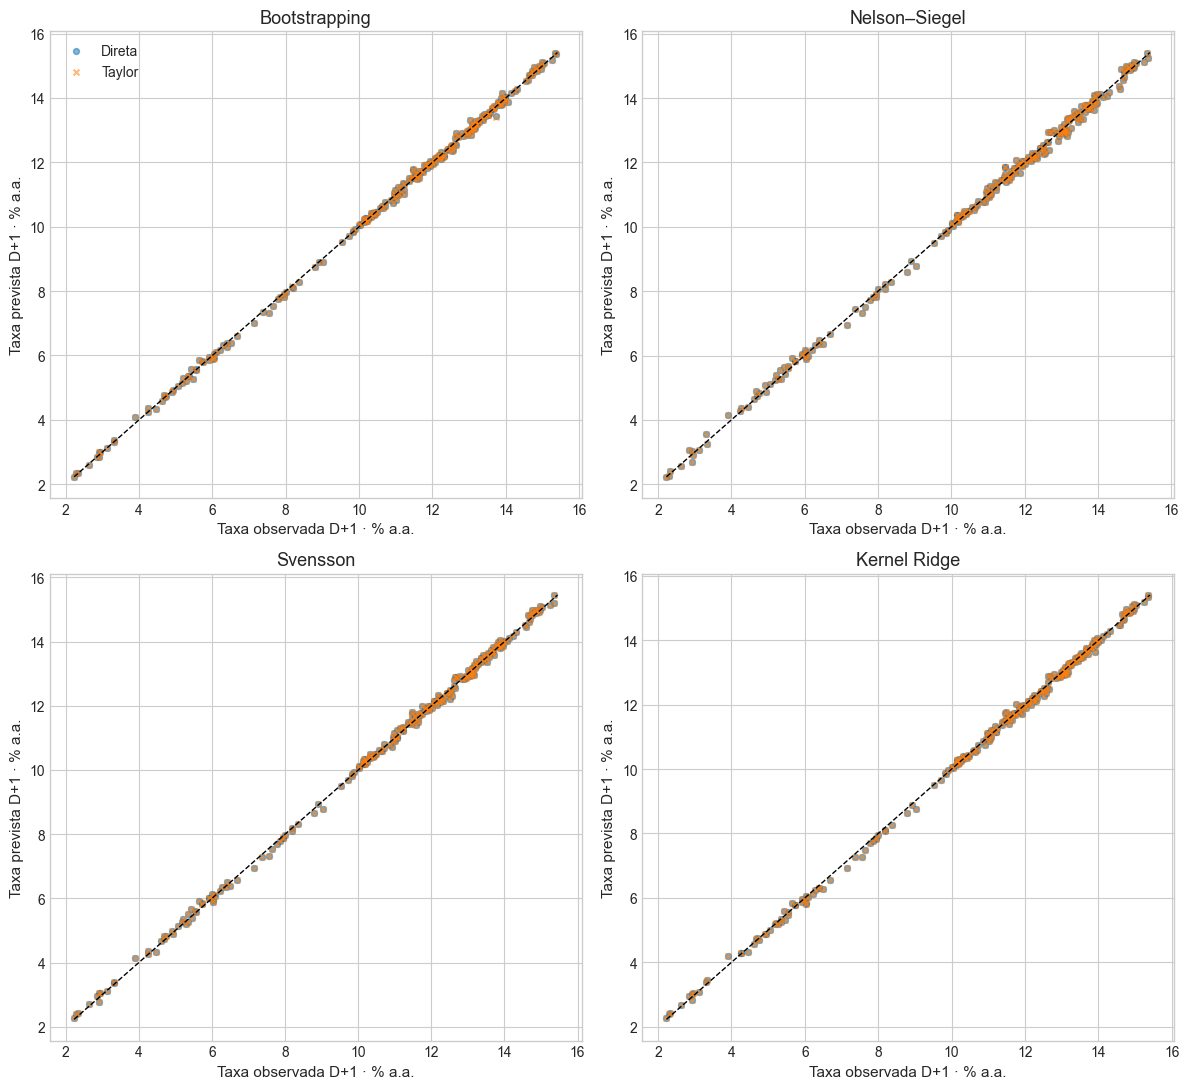

In [17]:
rolldown = read_result("rolldown_results")

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for axis, method in zip(axes.flat, METHOD_ORDER):
    subset = rolldown.loc[rolldown["methodology"].eq(method)]
    axis.scatter(subset["actual_rate_d1"] * 100, subset["predicted_rate_d1_direct"] * 100, s=18, alpha=0.55, label="Direta")
    axis.scatter(subset["actual_rate_d1"] * 100, subset["predicted_rate_d1_taylor"] * 100, s=18, alpha=0.55, marker="x", label="Taylor")
    limits = [
        100 * subset[["actual_rate_d1", "predicted_rate_d1_direct", "predicted_rate_d1_taylor"]].min().min(),
        100 * subset[["actual_rate_d1", "predicted_rate_d1_direct", "predicted_rate_d1_taylor"]].max().max(),
    ]
    axis.plot(limits, limits, "--", color="black", linewidth=1)
    axis.set_title(METHOD_LABELS[method])
    axis.set_xlabel("Taxa observada D+1 · % a.a.")
    axis.set_ylabel("Taxa prevista D+1 · % a.a.")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

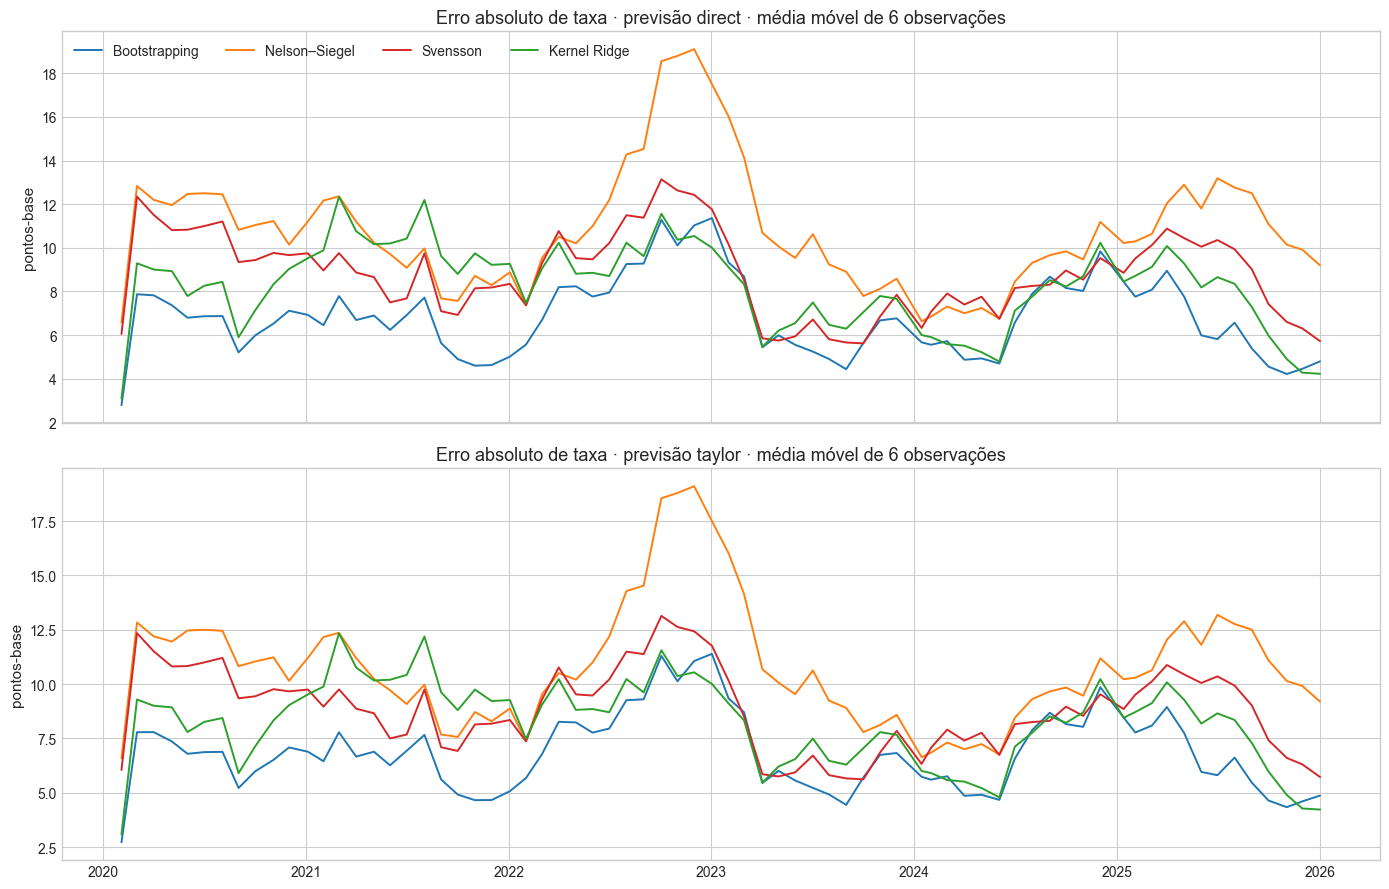

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for axis, prediction_method in zip(axes, ["direct", "taylor"]):
    error_column = f"rate_error_{prediction_method}"
    for method in METHOD_ORDER:
        line = rolldown.loc[rolldown["methodology"].eq(method)].sort_values("ref_date")
        monthly_mae = line.groupby("ref_date", observed=True)[error_column].apply(lambda values: values.abs().mean()).mul(10_000).rolling(6, min_periods=2).mean()
        axis.plot(monthly_mae.index, monthly_mae, label=METHOD_LABELS[method], color=METHOD_COLORS[method], linewidth=1.4)
    axis.set_title(f"Erro absoluto de taxa · previsão {prediction_method} · média móvel de 6 observações")
    axis.set_ylabel("pontos-base")
axes[0].legend(ncol=4, loc="upper left")
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## Quadro comparativo inicial

O quadro abaixo não substitui a análise econômica. Ele apenas reúne alguns indicadores globais para facilitar a identificação das metodologias que merecem investigação detalhada.

In [19]:
scorecard = (
    rate_summary.pivot(index="methodology", columns="sample", values="rmse_bp")
    .rename(columns={"in_sample": "rate_rmse_in_bp", "out_of_sample": "rate_rmse_out_bp"})
)
scorecard = scorecard.join(
    price_summary.pivot(index="methodology", columns="sample", values="rmse")
    .rename(columns={"in_sample": "price_rmse_in", "out_of_sample": "price_rmse_out"})
)
scorecard = scorecard.join(
    forward_daily.groupby("methodology", observed=True)["violation_share"].mean().mul(100).rename("mean_forward_violation_pct")
)
scorecard = scorecard.join(
    rolldown_metrics.groupby("methodology", observed=True)["rate_rmse_bp"].mean().rename("mean_rolldown_rmse_bp")
)
scorecard["pca_3f_explained_pct"] = explained.sum(axis=1) * 100
scorecard = scorecard.reindex(METHOD_ORDER)
scorecard.index = scorecard.index.map(METHOD_LABELS)
display(scorecard.style.background_gradient(cmap="RdYlGn_r", axis=0).format("{:.3f}"))

,rate_rmse_in_bp,rate_rmse_out_bp,price_rmse_in,price_rmse_out,mean_forward_violation_pct,mean_rolldown_rmse_bp,pca_3f_explained_pct
methodology,,,,,,,
Bootstrapping,0.924,40.859,0.362,10.175,0.019,8.401,99.076
Nelson–Siegel,40.675,64.613,1.665,15.468,0.282,13.272,99.394
Svensson,24.062,756.449,1.359,1517196978978880385143002179571946090464804864.000,19.115,10.214,99.996
Kernel Ridge,23.602,53.176,1.862,9.107,0.018,9.840,97.799


### Próximas extensões sugeridas

- segmentar RMSE e reprecificação por faixa de prazo;
- comparar os resultados antes e depois de datas de estresse;
- medir persistência e duração das violações de forward;
- acrescentar intervalos de confiança por bootstrap temporal;
- investigar separadamente datas em que `pricing_status` ou `invalid_forward` sinalizam extrapolação fora do domínio.